# CIL Training — Equipo 25
# Conditional Imitation Learning (Codevilla, ICRA 2018)
# Referencia arquitectura: https://github.com/carla-simulator/imitation-learning
# MR4010 Proyecto Final — Tecnológico de Monterrey MNA

In [45]:
import sys, os

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/MR4010_proyecto_final_2026'
else:
    BASE = '/Users/joelbecerril/MNA_WORKSPACE/NAVEGACION_AUTONOMA/Semana_9/ActFinal/MR4010_proyecto_final_2026'

CSV_PATH  = os.path.join(BASE, 'data', 'dataset_final.csv')
MODEL_OUT = os.path.join(BASE, 'models', 'cil_model_equipo25.h5')
os.makedirs(os.path.join(BASE, 'models'), exist_ok=True)

print('BASE     :', BASE)
print('CSV      :', CSV_PATH)
print('MODEL_OUT:', MODEL_OUT)
print('CSV existe:', os.path.exists(CSV_PATH))


BASE     : /Users/joelbecerril/MNA_WORKSPACE/NAVEGACION_AUTONOMA/Semana_9/ActFinal/MR4010_proyecto_final_2026
CSV      : /Users/joelbecerril/MNA_WORKSPACE/NAVEGACION_AUTONOMA/Semana_9/ActFinal/MR4010_proyecto_final_2026/data/dataset_final.csv
MODEL_OUT: /Users/joelbecerril/MNA_WORKSPACE/NAVEGACION_AUTONOMA/Semana_9/ActFinal/MR4010_proyecto_final_2026/models/cil_model_equipo25.h5
CSV existe: True


In [46]:
import csv, random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from PIL import Image, ImageEnhance
from collections import Counter

print('TensorFlow:', tf.__version__)
print('GPU disponible:', tf.config.list_physical_devices('GPU'))
print('CPU disponible:', tf.config.list_physical_devices('CPU'))

# Semilla reproducible
tf.random.set_seed(42)
random.seed(42)
np.random.seed(42)


TensorFlow: 2.18.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
CPU disponible: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [47]:
rows  = list(csv.DictReader(open(CSV_PATH)))
cmds  = Counter(int(r['nav_command']) for r in rows)
total = len(rows)
labels = {0:'CONTINUE', 1:'RECTO', 2:'IZQUIERDA', 3:'DERECHA'}

print(f'Total filas: {total:,}')
for c in range(4):
    n   = cmds[c]
    bar = '█' * int(n / total * 40)
    print(f'  {labels[c]:10s}: {n:6,} ({n/total*100:5.1f}%) {bar}')

zeros = sum(1 for r in rows if abs(float(r['steering_angle'])) < 0.01)
print(f'\nSteering ≈ 0 : {zeros:,} ({zeros/total*100:.1f}%)')
steers = [abs(float(r['steering_angle'])) for r in rows]
print(f'Steer máx    : {max(steers):.4f} rad')
print(f'Steer media  : {np.mean(steers):.4f} rad')


Total filas: 34,894
  CONTINUE  : 24,178 ( 69.3%) ███████████████████████████
  RECTO     :  1,068 (  3.1%) █
  IZQUIERDA :  5,204 ( 14.9%) █████
  DERECHA   :  4,444 ( 12.7%) █████

Steering ≈ 0 : 17,729 (50.8%)
Steer máx    : 0.5000 rad
Steer media  : 0.0458 rad


In [48]:
IMG_W, IMG_H = 200, 88
N_COMMANDS   = 4
MAX_STEER    = 0.5
BATCH_SIZE   = 120
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)


# ── Augmentations ─────────────────────────────────────────────────────────────

def aug_brightness(img_arr):
    """Cambio de brillo ±30%."""
    factor = np.random.uniform(0.70, 1.30)
    return np.clip(img_arr * factor, 0.0, 1.0)

def aug_contrast(img_arr):
    """Cambio de contraste alrededor de la media."""
    factor = np.random.uniform(0.70, 1.30)
    mean   = img_arr.mean()
    return np.clip((img_arr - mean) * factor + mean, 0.0, 1.0)

def aug_shadow(img_arr):
    """
    Sombra triangular aleatoria (simula árboles, edificios).
    Oscurece una mitad de la imagen con un polígono aleatorio.
    """
    h, w, _ = img_arr.shape
    x1, x2  = np.random.randint(0, w, 2)
    mask     = np.zeros((h, w), dtype=np.float32)
    for row in range(h):
        col = int(x1 + (x2 - x1) * row / h)
        if np.random.rand() < 0.5:
            mask[row, :col] = 1
        else:
            mask[row, col:] = 1
    shadow  = np.random.uniform(0.45, 0.75)
    out     = img_arr.copy()
    out[mask == 1] *= shadow
    return np.clip(out, 0.0, 1.0)

def aug_noise(img_arr):
    """Ruido gaussiano leve."""
    noise = np.random.normal(0, 0.02, img_arr.shape).astype(np.float32)
    return np.clip(img_arr + noise, 0.0, 1.0)

def aug_zoom(img_arr):
    """Recorte central leve (zoom 5-15%) para simular variación de altura de cámara."""
    from PIL import Image as PILImage
    h, w, _ = img_arr.shape
    crop = np.random.uniform(0.05, 0.12)
    cy   = int(h * crop)
    cx   = int(w * crop)
    cropped = img_arr[cy:h-cy, cx:w-cx, :]
    out = np.array(PILImage.fromarray((cropped * 255).astype(np.uint8)).resize((w, h)),
                   dtype=np.float32) / 255.0
    return out

def apply_augmentation(img_arr):
    """Aplica augmentations aleatorias en secuencia."""
    if np.random.rand() < 0.6:
        img_arr = aug_brightness(img_arr)
    if np.random.rand() < 0.4:
        img_arr = aug_contrast(img_arr)
    if np.random.rand() < 0.5:
        img_arr = aug_shadow(img_arr)
    if np.random.rand() < 0.3:
        img_arr = aug_noise(img_arr)
    if np.random.rand() < 0.3:
        img_arr = aug_zoom(img_arr)
    return img_arr


def load_image(path, augment=False):
    from PIL import Image as PILImage
    img = PILImage.open(path).convert('RGB').resize((IMG_W, IMG_H))
    arr = np.array(img, dtype=np.float32) / 255.0
    if augment:
        arr = apply_augmentation(arr)
    arr = (arr - MEAN) / STD
    return arr


class CILSequence(keras.utils.Sequence):

    def __init__(self, rows, base_dir, augment=False):
        self.rows    = rows
        self.base    = base_dir
        self.augment = augment
        self.indices = list(range(len(rows)))
        if augment:
            random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.rows) / BATCH_SIZE))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * BATCH_SIZE: (idx + 1) * BATCH_SIZE]
        imgs, spds, cmds, steers = [], [], [], []

        for i in batch_idx:
            row   = self.rows[i]
            steer = float(row['steering_angle'])
            cmd   = int(row['nav_command'])
            speed = float(row['speed_kmh']) / 30.0

            path = os.path.join(self.base, row['image_path'])
            flip = self.augment and random.random() < 0.5

            arr = load_image(path, augment=self.augment)
            if flip:
                arr   = arr[:, ::-1, :].copy()
                steer = -steer
                cmd   = 3 if cmd == 2 else (2 if cmd == 3 else cmd)

            steer_norm = float(np.clip(steer / MAX_STEER, -1.0, 1.0))
            imgs.append(arr)
            spds.append([speed])
            cmd_oh = np.zeros(N_COMMANDS, dtype=np.float32)
            cmd_oh[cmd] = 1.0
            cmds.append(cmd_oh)
            steers.append([steer_norm])

        return (
            {'image':   np.array(imgs,   dtype=np.float32),
             'speed':   np.array(spds,   dtype=np.float32),
             'command': np.array(cmds,   dtype=np.float32)},
            np.array(steers, dtype=np.float32)
        )

    def on_epoch_end(self):
        if self.augment:
            random.shuffle(self.indices)


by_cmd = {c: [r for r in rows if int(r['nav_command']) == c] for c in range(4)}
train_rows, val_rows = [], []
for c, rws in by_cmd.items():
    random.shuffle(rws)
    cut = int(len(rws) * 0.85)
    train_rows += rws[:cut]
    val_rows   += rws[cut:]
random.shuffle(train_rows)

train_gen = CILSequence(train_rows, BASE, augment=True)
val_gen   = CILSequence(val_rows,   BASE, augment=False)

print(f'Train: {len(train_rows):,} muestras ({len(train_gen)} batches)')
print(f'Val  : {len(val_rows):,} muestras ({len(val_gen)} batches)')
print()
print('Augmentations activas:')
print('  ✓ Flip horizontal + inversión steering + swap IZQ↔DER (p=0.5)')
print('  ✓ Brillo aleatorio ±30%          (p=0.6)')
print('  ✓ Contraste aleatorio ±30%       (p=0.4)')
print('  ✓ Sombra triangular aleatoria    (p=0.5)  ← nueva')
print('  ✓ Ruido gaussiano σ=0.02         (p=0.3)  ← nueva')
print('  ✓ Zoom aleatorio 5-12%           (p=0.3)  ← nueva')


Train: 29,658 muestras (248 batches)
Val  : 5,236 muestras (44 batches)

Augmentations activas:
  ✓ Flip horizontal + inversión steering + swap IZQ↔DER (p=0.5)
  ✓ Brillo aleatorio ±30%          (p=0.6)
  ✓ Contraste aleatorio ±30%       (p=0.4)
  ✓ Sombra triangular aleatoria    (p=0.5)  ← nueva
  ✓ Ruido gaussiano σ=0.02         (p=0.3)  ← nueva
  ✓ Zoom aleatorio 5-12%           (p=0.3)  ← nueva


In [49]:
# ── Validación de carga de imágenes ──────────────────────────────────────────
import os
from collections import Counter

print("=" * 60)
print("VALIDACIÓN DE DATASET")
print("=" * 60)

# 1. Conteo total en CSV
print(f"\n1. FILAS EN CSV")
print(f"   Total filas:    {len(rows):,}")
print(f"   Train:          {len(train_rows):,}")
print(f"   Val:            {len(val_rows):,}")
print(f"   Ratio val:      {len(val_rows)/len(rows)*100:.1f}%")

# 2. Verificar que todas las imágenes existen en disco
print(f"\n2. IMÁGENES EN DISCO")
missing = [r['image_path'] for r in rows if not os.path.exists(os.path.join(BASE, r['image_path']))]
print(f"   Imágenes en CSV:      {len(rows):,}")
print(f"   Imágenes faltantes:   {len(missing)}", "✓" if not missing else "✗ ERROR")
if missing:
    for p in missing[:5]:
        print(f"   - {p}")

# 3. Distribución de comandos en train/val
print(f"\n3. DISTRIBUCIÓN nav_command")
labels = {0:'CONTINUE', 1:'LEFT', 2:'RIGHT', 3:'STRAIGHT'}
for split_name, split_rows in [('Train', train_rows), ('Val', val_rows)]:
    cc = Counter(int(r['nav_command']) for r in split_rows)
    total = len(split_rows)
    parts = [f"{labels[c]}={cc[c]}({cc[c]/total*100:.0f}%)" for c in range(4)]
    print(f"   {split_name}: {' | '.join(parts)}")

# 4. Probar carga real de un batch
print(f"\n4. PRUEBA DE CARGA (1 batch de train)")
import numpy as np
batch_x, batch_y = train_gen[0]
imgs  = batch_x['image']
spds  = batch_x['speed']
cmds  = batch_x['command']
print(f"   image  shape: {imgs.shape}   dtype: {imgs.dtype}")
print(f"   speed  shape: {spds.shape}   dtype: {spds.dtype}")
print(f"   command shape: {cmds.shape}  dtype: {cmds.dtype}")
print(f"   steering shape: {batch_y.shape}  dtype: {batch_y.dtype}")
print(f"   image  rango: [{imgs.min():.2f}, {imgs.max():.2f}]")
print(f"   speed  rango: [{spds.min():.2f}, {spds.max():.2f}]")
print(f"   steer  rango: [{batch_y.min():.3f}, {batch_y.max():.3f}]")
# Verificar que cmd es one-hot
assert cmds.shape[1] == N_COMMANDS, f"cmd shape incorrecto: {cmds.shape}"
assert np.all(cmds.sum(axis=1) == 1.0), "cmd NO es one-hot válido"
print(f"   command: one-hot válido ✓  (shape {cmds.shape})")

# 5. Totales por fuente si existe columna source
sources = Counter(r.get('source','?') for r in rows)
print(f"\n5. FUENTE DE DATOS")
for src, n in sorted(sources.items(), key=lambda x: -x[1]):
    print(f"   {src:25s}: {n:6,} ({100*n/len(rows):.1f}%)")

print("\n" + "=" * 60)
print("Dataset listo para entrenamiento ✓" if not missing else "⚠ Corrige las imágenes faltantes antes de entrenar")
print("=" * 60)


VALIDACIÓN DE DATASET

1. FILAS EN CSV
   Total filas:    34,894
   Train:          29,658
   Val:            5,236
   Ratio val:      15.0%

2. IMÁGENES EN DISCO
   Imágenes en CSV:      34,894
   Imágenes faltantes:   0 ✓

3. DISTRIBUCIÓN nav_command
   Train: CONTINUE=20551(69%) | LEFT=907(3%) | RIGHT=4423(15%) | STRAIGHT=3777(13%)
   Val: CONTINUE=3627(69%) | LEFT=161(3%) | RIGHT=781(15%) | STRAIGHT=667(13%)

4. PRUEBA DE CARGA (1 batch de train)
   image  shape: (120, 88, 200, 3)   dtype: float32
   speed  shape: (120, 1)   dtype: float32
   command shape: (120, 4)  dtype: float32
   steering shape: (120, 1)  dtype: float32
   image  rango: [-2.12, 2.64]
   speed  rango: [0.33, 1.62]
   steer  rango: [-0.750, 0.507]
   command: one-hot válido ✓  (shape (120, 4))

5. FUENTE DE DATOS
   manual_jun23             : 15,394 (44.1%)
   alberto                  : 10,313 (29.6%)
   joel                     :  9,187 (26.3%)

Dataset listo para entrenamiento ✓


In [50]:
def build_cil_model(n_commands=4, img_h=88, img_w=200):
    """
    Arquitectura Codevilla 2018 (ICRA) implementada en Keras.
    Ref: github.com/carla-simulator/imitation-learning

    Entradas:
      image   : (H, W, 3) imagen de cámara normalizada
      speed   : (1,)      velocidad normalizada [0,1]
      command : (n_commands,)  one-hot float — pre-calculado en el generador

    Salida:
      steering_norm : (1,) en [-1, 1]  →  multiplicar por MAX_STEER para rad
    """
    # ── Entradas ──────────────────────────────────────────────────────────────
    img_in = Input(shape=(img_h, img_w, 3), name='image')
    spd_in = Input(shape=(1,),              name='speed')
    cmd_in = Input(shape=(n_commands,),     name='command')   # one-hot float, sin Lambda

    # ── CNN backbone (8 capas conv, Codevilla) ────────────────────────────────
    # Bloque 1
    x = layers.Conv2D(32, 5, strides=2, padding='valid')(img_in)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(32, 3, strides=1, padding='valid')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.ReLU()(x)

    # Bloque 2
    x = layers.Conv2D(64, 3, strides=2, padding='valid')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(64, 3, strides=1, padding='valid')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.ReLU()(x)

    # Bloque 3
    x = layers.Conv2D(128, 3, strides=2, padding='valid')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(128, 3, strides=1, padding='valid')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.ReLU()(x)

    # Bloque 4
    x = layers.Conv2D(256, 3, strides=1, padding='valid')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(256, 3, strides=1, padding='valid')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.ReLU()(x)

    # ── FC imagen ─────────────────────────────────────────────────────────────
    x = layers.Flatten()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.2)(x)

    # ── Rama de velocidad ─────────────────────────────────────────────────────
    s = layers.Dense(128, activation='relu')(spd_in)
    s = layers.Dense(128, activation='relu')(s)

    # ── Concatenar + FC conjunto ──────────────────────────────────────────────
    joined = layers.Concatenate()([x, s])
    joined = layers.Dense(512, activation='relu')(joined)

    # ── 4 ramas de comando (una por acción) ───────────────────────────────────
    branch_outs = []
    for i in range(n_commands):
        b = layers.Dense(256, activation='relu')(joined)
        b = layers.Dropout(0.5)(b)
        b = layers.Dense(256, activation='relu')(b)
        b = layers.Dense(1,   activation='tanh', name=f'branch_{i}')(b)
        branch_outs.append(b)                  # cada b: (batch, 1)

    # ── Selección de rama por comando ─────────────────────────────────────────
    # cmd_in ya es one-hot float (batch, n_commands) → no necesita Lambda
    all_branches = layers.Concatenate(name='all_branches')(branch_outs)  # (batch, n_commands)
    selected     = layers.Multiply(name='branch_select')([all_branches, cmd_in])
    # Dense(1, use_bias=False) con pesos fijos = reduce_sum serializable
    output       = layers.Dense(
        1, use_bias=False,
        kernel_initializer='ones',
        trainable=False,
        name='steering'
    )(selected)

    model = Model(inputs=[img_in, spd_in, cmd_in], outputs=output, name='CIL_Codevilla')
    return model


model = build_cil_model(N_COMMANDS, IMG_H, IMG_W)
model.summary()
print(f'\nParámetros totales: {model.count_params():,}')


Model: "CIL_Codevilla"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 88, 200,   │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 42, 98,    │      2,432 │ image[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 42, 98,    │        128 │ conv2d_24[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_42          │ (None, 42, 98,    │          0 │ batch_normalizat… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_24 (ReLU)     │ (None, 42, 98,    │          0 │ dropout_42[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 40, 96,    │      9,248 │ re_lu_24[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 96,    │        128 │ conv2d_25[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_43          │ (None, 40, 96,    │          0 │ batch_normalizat… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_25 (ReLU)     │ (None, 40, 96,    │          0 │ dropout_43[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 19, 47,    │     18,496 │ re_lu_25[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 19, 47,    │        256 │ conv2d_26[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_44          │ (None, 19, 47,    │          0 │ batch_normalizat… │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_26 (ReLU)     │ (None, 19, 47,    │          0 │ dropout_44[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 17, 45,    │     36,928 │ re_lu_26[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 17, 45,    │        256 │ conv2d_27[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_45          │ (None, 17, 45,    │          0 │ batch_normalizat… │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_27 (ReLU)     │ (None, 17, 45,    │          0 │ dropout_45[0][0]

 Total params: 6,769,576 (25.82 MB)

 Trainable params: 6,767,652 (25.82 MB)

 Non-trainable params: 1,924 (7.52 KB)


Parámetros totales: 6,769,576


In [51]:
EPOCHS = 40
LR     = 1e-4
TOL_RAD = 0.05   # tolerancia para métrica de accuracy (±0.05 rad ≈ ±2.9°)

# Loss ponderada: curvas (|steer_norm| > 0.2) pesan 5× más
def weighted_mse(y_true, y_pred):
    weight = 1.0 + 4.0 * tf.cast(tf.abs(y_true) > 0.2, tf.float32)
    return tf.reduce_mean(weight * tf.square(y_pred - y_true))

# Métrica: fracción de predicciones dentro de ±TOL_RAD (en rad)
def steer_accuracy(y_true, y_pred):
    err_rad = tf.abs(y_pred - y_true) * MAX_STEER
    return tf.reduce_mean(tf.cast(err_rad < TOL_RAD, tf.float32))

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss=weighted_mse,
    metrics=[steer_accuracy, 'mae']
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        MODEL_OUT, monitor='val_loss', save_best_only=True,
        verbose=1, mode='min'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=7,
        min_lr=1e-6, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=12, restore_best_weights=True, verbose=1
    ),
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/40
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - loss: 1.2495 - mae: 0.8462 - steer_accuracy: 0.0262
Epoch 1: val_loss improved from None to 0.94161, saving model to /Users/joelbecerril/MNA_WORKSPACE/NAVEGACION_AUTONOMA/Semana_9/ActFinal/MR4010_proyecto_final_2026/models/cil_model_equipo25.h5



Epoch 1: finished saving model to /Users/joelbecerril/MNA_WORKSPACE/NAVEGACION_AUTONOMA/Semana_9/ActFinal/MR4010_proyecto_final_2026/models/cil_model_equipo25.h5
248/248 ━━━━━━━━━━━━━━━━━━━━ 59s 217ms/step - loss: 1.2802 - mae: 0.8641 - steer_accuracy: 0.0219 - val_loss: 0.9416 - val_mae: 0.7480 - val_steer_accuracy: 0.0071 - learning_rate: 1.0000e-04
Epoch 2/40
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - loss: 1.3376 - mae: 0.8911 - steer_accuracy: 0.0175
Epoch 2: val_loss did not improve from 0.94161
248/248 ━━━━━━━━━━━━━━━━━━━━ 55s 220ms/step - loss: 1.3359 - mae: 0.8936 - steer_accuracy: 0.0173 - val_loss: 1.3990 - val_mae: 0.9423 - val_steer_accuracy: 0.0071 - learning_rate: 1.0000e-04
Epoch 3/40
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - loss: 1.3558 - mae: 0.9134 - steer_accuracy: 0.0144
Epoch 3: val_loss improved from 0.94161 to 0.55580, saving model to /Users/joelbecerril/MNA_WORKSPACE/NAVEGACION_AUTONOMA/Semana_9/ActFinal/MR4010_proyecto_final_2026/models/cil_model_equipo


Epoch 3: finished saving model to /Users/joelbecerril/MNA_WORKSPACE/NAVEGACION_AUTONOMA/Semana_9/ActFinal/MR4010_proyecto_final_2026/models/cil_model_equipo25.h5
248/248 ━━━━━━━━━━━━━━━━━━━━ 54s 218ms/step - loss: 1.3763 - mae: 0.9135 - steer_accuracy: 0.0145 - val_loss: 0.5558 - val_mae: 0.4343 - val_steer_accuracy: 0.2000 - learning_rate: 1.0000e-04
Epoch 4/40
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - loss: 1.3125 - mae: 0.8970 - steer_accuracy: 0.0176
Epoch 4: val_loss did not improve from 0.55580
248/248 ━━━━━━━━━━━━━━━━━━━━ 59s 236ms/step - loss: 1.3120 - mae: 0.8882 - steer_accuracy: 0.0183 - val_loss: 1.1673 - val_mae: 0.8145 - val_steer_accuracy: 0.0160 - learning_rate: 1.0000e-04
Epoch 5/40
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - loss: 1.2023 - mae: 0.8273 - steer_accuracy: 0.0293
Epoch 5: val_loss improved from 0.55580 to 0.51980, saving model to /Users/joelbecerril/MNA_WORKSPACE/NAVEGACION_AUTONOMA/Semana_9/ActFinal/MR4010_proyecto_final_2026/models/cil_model_equipo


Epoch 5: finished saving model to /Users/joelbecerril/MNA_WORKSPACE/NAVEGACION_AUTONOMA/Semana_9/ActFinal/MR4010_proyecto_final_2026/models/cil_model_equipo25.h5
248/248 ━━━━━━━━━━━━━━━━━━━━ 61s 244ms/step - loss: 1.1290 - mae: 0.7891 - steer_accuracy: 0.0373 - val_loss: 0.5198 - val_mae: 0.4630 - val_steer_accuracy: 0.0793 - learning_rate: 1.0000e-04
Epoch 6/40
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - loss: 0.9658 - mae: 0.6949 - steer_accuracy: 0.0585
Epoch 6: val_loss did not improve from 0.51980
248/248 ━━━━━━━━━━━━━━━━━━━━ 64s 259ms/step - loss: 0.9756 - mae: 0.7058 - steer_accuracy: 0.0560 - val_loss: 0.6268 - val_mae: 0.5171 - val_steer_accuracy: 0.0664 - learning_rate: 1.0000e-04
Epoch 7/40
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - loss: 0.9064 - mae: 0.6624 - steer_accuracy: 0.0719
Epoch 7: val_loss improved from 0.51980 to 0.49363, saving model to /Users/joelbecerril/MNA_WORKSPACE/NAVEGACION_AUTONOMA/Semana_9/ActFinal/MR4010_proyecto_final_2026/models/cil_model_equipo


Epoch 7: finished saving model to /Users/joelbecerril/MNA_WORKSPACE/NAVEGACION_AUTONOMA/Semana_9/ActFinal/MR4010_proyecto_final_2026/models/cil_model_equipo25.h5
248/248 ━━━━━━━━━━━━━━━━━━━━ 70s 281ms/step - loss: 0.8399 - mae: 0.6195 - steer_accuracy: 0.0911 - val_loss: 0.4936 - val_mae: 0.3962 - val_steer_accuracy: 0.3102 - learning_rate: 1.0000e-04
Epoch 8/40
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - loss: 0.7310 - mae: 0.5534 - steer_accuracy: 0.1215
Epoch 8: val_loss did not improve from 0.49363
248/248 ━━━━━━━━━━━━━━━━━━━━ 69s 277ms/step - loss: 0.7384 - mae: 0.5543 - steer_accuracy: 0.1246 - val_loss: 1.0804 - val_mae: 0.5989 - val_steer_accuracy: 0.2060 - learning_rate: 1.0000e-04
Epoch 9/40
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - loss: 0.6760 - mae: 0.5108 - steer_accuracy: 0.1612
Epoch 9: val_loss did not improve from 0.49363
248/248 ━━━━━━━━━━━━━━━━━━━━ 66s 267ms/step - loss: 0.6442 - mae: 0.4974 - steer_accuracy: 0.1719 - val_loss: 0.9248 - val_mae: 0.6486 - val_st


Epoch 10: finished saving model to /Users/joelbecerril/MNA_WORKSPACE/NAVEGACION_AUTONOMA/Semana_9/ActFinal/MR4010_proyecto_final_2026/models/cil_model_equipo25.h5
248/248 ━━━━━━━━━━━━━━━━━━━━ 68s 274ms/step - loss: 0.6159 - mae: 0.4785 - steer_accuracy: 0.1768 - val_loss: 0.4474 - val_mae: 0.3100 - val_steer_accuracy: 0.4406 - learning_rate: 1.0000e-04
Epoch 11/40
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - loss: 0.5382 - mae: 0.4306 - steer_accuracy: 0.2087
Epoch 11: val_loss did not improve from 0.44737
248/248 ━━━━━━━━━━━━━━━━━━━━ 71s 286ms/step - loss: 0.5474 - mae: 0.4375 - steer_accuracy: 0.1971 - val_loss: 0.5318 - val_mae: 0.3745 - val_steer_accuracy: 0.3219 - learning_rate: 1.0000e-04
Epoch 12/40
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - loss: 0.5971 - mae: 0.4657 - steer_accuracy: 0.1801
Epoch 12: val_loss did not improve from 0.44737
248/248 ━━━━━━━━━━━━━━━━━━━━ 70s 283ms/step - loss: 0.6048 - mae: 0.4794 - steer_accuracy: 0.1654 - val_loss: 0.8515 - val_mae: 0.6471 - v


Epoch 19: finished saving model to /Users/joelbecerril/MNA_WORKSPACE/NAVEGACION_AUTONOMA/Semana_9/ActFinal/MR4010_proyecto_final_2026/models/cil_model_equipo25.h5
248/248 ━━━━━━━━━━━━━━━━━━━━ 72s 291ms/step - loss: 0.7066 - mae: 0.5347 - steer_accuracy: 0.1315 - val_loss: 0.4303 - val_mae: 0.3096 - val_steer_accuracy: 0.4743 - learning_rate: 5.0000e-05
Epoch 20/40
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - loss: 0.6052 - mae: 0.4763 - steer_accuracy: 0.1858
Epoch 20: val_loss improved from 0.43027 to 0.20374, saving model to /Users/joelbecerril/MNA_WORKSPACE/NAVEGACION_AUTONOMA/Semana_9/ActFinal/MR4010_proyecto_final_2026/models/cil_model_equipo25.h5



Epoch 20: finished saving model to /Users/joelbecerril/MNA_WORKSPACE/NAVEGACION_AUTONOMA/Semana_9/ActFinal/MR4010_proyecto_final_2026/models/cil_model_equipo25.h5
248/248 ━━━━━━━━━━━━━━━━━━━━ 71s 285ms/step - loss: 0.5688 - mae: 0.4480 - steer_accuracy: 0.2073 - val_loss: 0.2037 - val_mae: 0.2064 - val_steer_accuracy: 0.3260 - learning_rate: 5.0000e-05
Epoch 21/40
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - loss: 0.5282 - mae: 0.4260 - steer_accuracy: 0.2123
Epoch 21: val_loss did not improve from 0.20374
248/248 ━━━━━━━━━━━━━━━━━━━━ 75s 302ms/step - loss: 0.5415 - mae: 0.4314 - steer_accuracy: 0.1982 - val_loss: 0.2478 - val_mae: 0.3120 - val_steer_accuracy: 0.1435 - learning_rate: 5.0000e-05
Epoch 22/40
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - loss: 0.5570 - mae: 0.4489 - steer_accuracy: 0.1706
Epoch 22: val_loss did not improve from 0.20374
248/248 ━━━━━━━━━━━━━━━━━━━━ 70s 282ms/step - loss: 0.6219 - mae: 0.4879 - steer_accuracy: 0.1459 - val_loss: 0.6850 - val_mae: 0.5367 - v

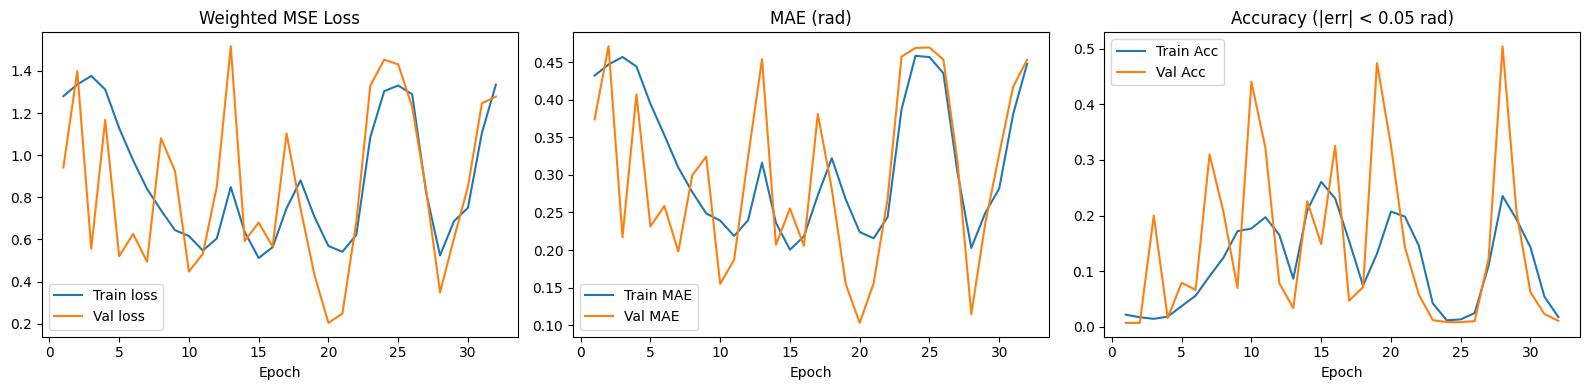

Mejor epoch    : 20/32
Mejor val_loss : 0.20374
Val MAE        : 0.1032 rad
Val Accuracy   : 32.6%
Modelo guardado: /Users/joelbecerril/MNA_WORKSPACE/NAVEGACION_AUTONOMA/Semana_9/ActFinal/MR4010_proyecto_final_2026/models/cil_model_equipo25.h5


In [52]:
import matplotlib.pyplot as plt

hist = history.history
epochs_ran = range(1, len(hist['loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs_ran, hist['loss'],     label='Train loss')
axes[0].plot(epochs_ran, hist['val_loss'], label='Val loss')
axes[0].set_title('Weighted MSE Loss')
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(epochs_ran, [v * MAX_STEER for v in hist['mae']],     label='Train MAE')
axes[1].plot(epochs_ran, [v * MAX_STEER for v in hist['val_mae']], label='Val MAE')
axes[1].set_title('MAE (rad)')
axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(epochs_ran, hist['steer_accuracy'],     label='Train Acc')
axes[2].plot(epochs_ran, hist['val_steer_accuracy'], label='Val Acc')
axes[2].set_title(f'Accuracy (|err| < {TOL_RAD} rad)')
axes[2].set_xlabel('Epoch'); axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(BASE, 'models', 'learning_curve.png'), dpi=120)
plt.show()

best_epoch = int(np.argmin(hist['val_loss'])) + 1
print(f"Mejor epoch    : {best_epoch}/{len(hist['loss'])}")
print(f"Mejor val_loss : {min(hist['val_loss']):.5f}")
print(f"Val MAE        : {hist['val_mae'][best_epoch-1]*MAX_STEER:.4f} rad")
print(f"Val Accuracy   : {hist['val_steer_accuracy'][best_epoch-1]*100:.1f}%")
print(f"Modelo guardado: {MODEL_OUT}")


In [53]:
# Verificación del modelo guardado e inferencia de prueba
model_loaded = keras.models.load_model(
    MODEL_OUT,
    custom_objects={'weighted_mse': weighted_mse, 'steer_accuracy': steer_accuracy},
    safe_mode=False
)
print(f"Modelo cargado: {MODEL_OUT}")
print(f"Entradas : {[i.name for i in model_loaded.inputs]}")
print(f"Salida   : {model_loaded.output.name}  shape={model_loaded.output.shape}")

# Inferencia con imagen negra (sanity check: salida no debe ser NaN)
dummy_img = np.zeros((1, IMG_H, IMG_W, 3), dtype=np.float32)
dummy_spd = np.array([[0.5]], dtype=np.float32)
label_map = {0:'CONTINUE', 1:'RECTO', 2:'IZQUIERDA', 3:'DERECHA'}

print('\nInferencia con imagen negra (debe ser ≠ NaN):')
for cmd in range(4):
    dummy_cmd = np.zeros((1, N_COMMANDS), dtype=np.float32)
    dummy_cmd[0, cmd] = 1.0
    pred_norm = model_loaded.predict(
        {'image': dummy_img, 'speed': dummy_spd, 'command': dummy_cmd},
        verbose=0
    )[0, 0]
    steer_rad = float(pred_norm) * MAX_STEER
    print(f"  CMD {cmd} ({label_map[cmd]:10s}): {steer_rad:+.4f} rad  (norm={pred_norm:+.4f})")

print('\nModelo Keras listo para autonomous_cil.py')


Modelo cargado: /Users/joelbecerril/MNA_WORKSPACE/NAVEGACION_AUTONOMA/Semana_9/ActFinal/MR4010_proyecto_final_2026/models/cil_model_equipo25.h5
Entradas : ['image', 'speed', 'command']
Salida   : keras_tensor_378  shape=(None, 1)

Inferencia con imagen negra (debe ser ≠ NaN):
  CMD 0 (CONTINUE  ): -0.0672 rad  (norm=-0.1344)
  CMD 1 (RECTO     ): +0.4417 rad  (norm=+0.8833)
  CMD 2 (IZQUIERDA ): -0.4563 rad  (norm=-0.9125)
  CMD 3 (DERECHA   ): +0.4929 rad  (norm=+0.9858)

Modelo Keras listo para autonomous_cil.py
